In [30]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer


In [32]:
with open('ultimate_data_challenge.json', 'r') as file:
    data = json.load(file)

In [33]:
df = pd.DataFrame(data)

In [36]:
df[['signup_date', 'last_trip_date']] = df[['signup_date', 'last_trip_date']].apply(pd.to_datetime)


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    50000 non-null  object        
 1   trips_in_first_30_days  50000 non-null  int64         
 2   signup_date             50000 non-null  datetime64[ns]
 3   avg_rating_of_driver    41878 non-null  float64       
 4   avg_surge               50000 non-null  float64       
 5   last_trip_date          50000 non-null  datetime64[ns]
 6   phone                   49604 non-null  object        
 7   surge_pct               50000 non-null  float64       
 8   ultimate_black_user     50000 non-null  bool          
 9   weekday_pct             50000 non-null  float64       
 10  avg_dist                50000 non-null  float64       
 11  avg_rating_by_driver    49799 non-null  float64       
dtypes: bool(1), datetime64[ns](2), float64(6), int

In [40]:
# -----------------------
# Create retention label
# -----------------------
data_pull_date = df["last_trip_date"].max()
cutoff = data_pull_date - pd.Timedelta(days=30)
df["retained"] = (df["last_trip_date"] >= cutoff).astype(int)
print("fraction of observed users retained:",(df["retained"] == 1).sum()/len(df["retained"]))

fraction of observed users retained: 0.37608


In [44]:
# Flag potentially problematic rows (not automatically dropped; we just report)
issues = {}
issues["neg_avg_dist"] = int((df["avg_dist"] < 0).sum())
issues["avg_surge_lt_1"] = int((df["avg_surge"] < 1).sum())
issues["surge_pct_outside_0_100"] = int(((df["surge_pct"] < 0) | (df["surge_pct"] > 100)).sum())
issues["weekday_pct_outside_0_100"] = int(((df["weekday_pct"] < 0) | (df["weekday_pct"] > 100)).sum())
issues["trips_negative"] = int((df["trips_in_first_30_days"] < 0).sum())
issues

{'neg_avg_dist': 0,
 'avg_surge_lt_1': 0,
 'surge_pct_outside_0_100': 0,
 'weekday_pct_outside_0_100': 0,
 'trips_negative': 0}

Retention rate by city:


city
King's Landing    0.628134
Winterfell        0.351945
Astapor           0.255715
Name: retained, dtype: float64

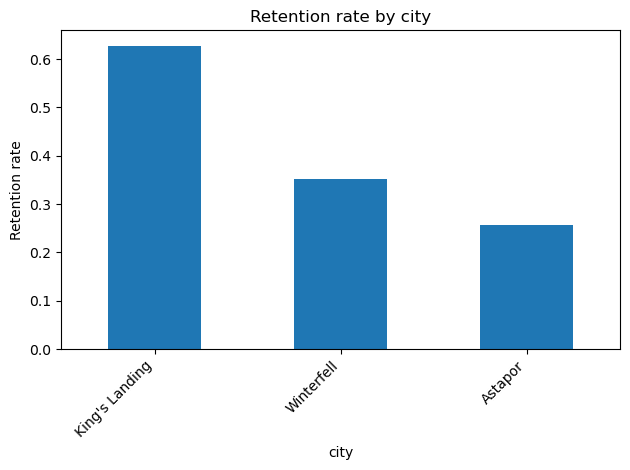

Retention rate by phone:


phone
iPhone     0.448933
Android    0.209426
Name: retained, dtype: float64

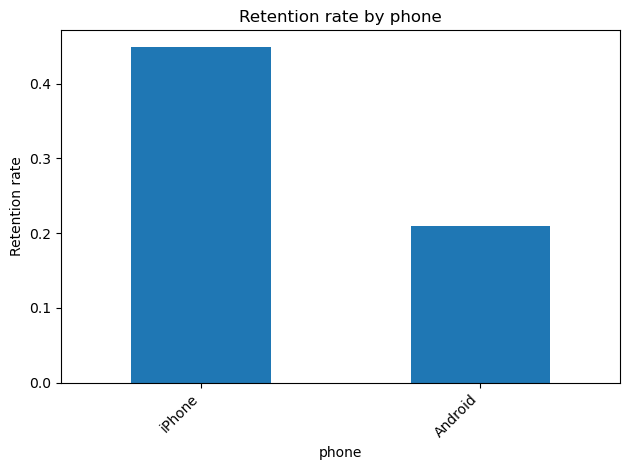

Retention rate by ultimate_black_user:


ultimate_black_user
True     0.503713
False    0.298818
Name: retained, dtype: float64

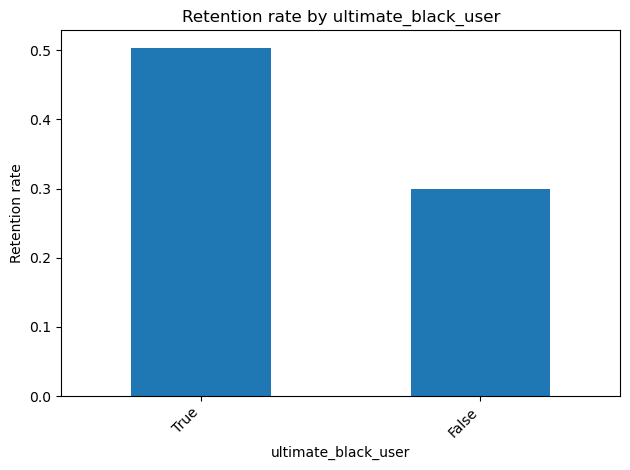

In [46]:
# Retention by categorical features
cat_cols = ["city", "phone", "ultimate_black_user"]

for col in cat_cols:
    rate = df.groupby(col)["retained"].mean().sort_values(ascending=False)
    print(f"Retention rate by {col}:")
    display(rate)
    plt.figure()
    rate.plot(kind="bar")
    plt.ylabel("Retention rate")
    plt.title(f"Retention rate by {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


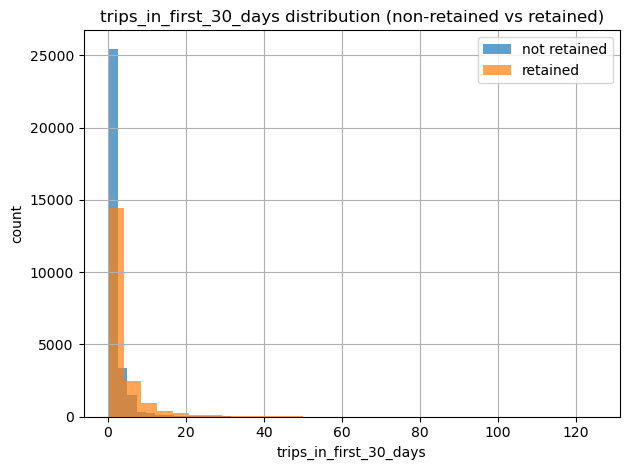

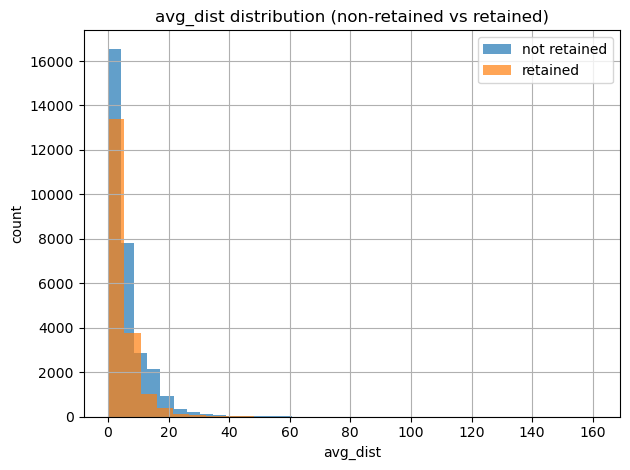

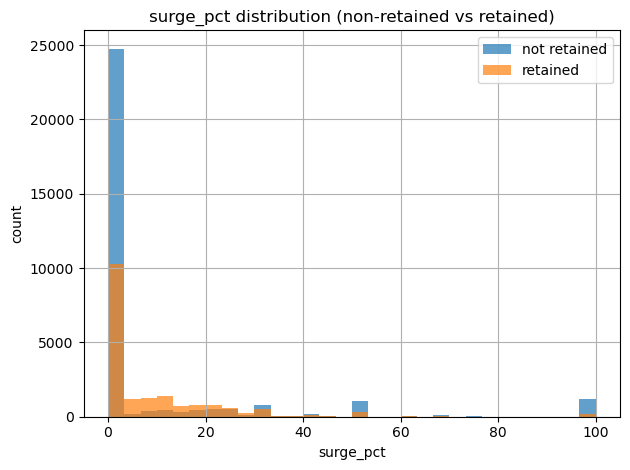

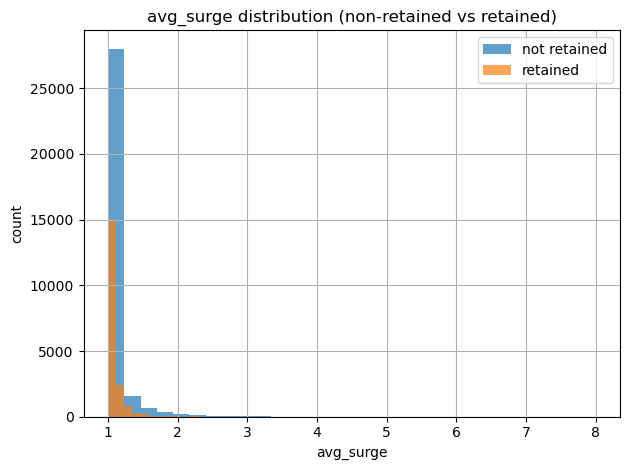

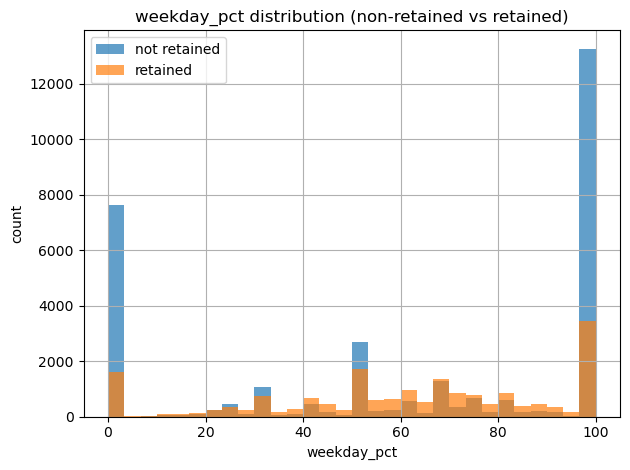

In [48]:
# Numeric distributions by retention
plot_cols = ["trips_in_first_30_days", "avg_dist", "surge_pct", "avg_surge", "weekday_pct"]

for col in plot_cols:
    plt.figure()
    df.loc[df["retained"] == 0, col].dropna().hist(bins=30, alpha=0.7)
    df.loc[df["retained"] == 1, col].dropna().hist(bins=30, alpha=0.7)
    plt.title(f"{col} distribution (non-retained vs retained)")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.legend(["not retained", "retained"])
    plt.tight_layout()
    plt.show()


In [49]:
# -----------------------
#  Quick EDA checks
# -----------------------
print("\nMissing values (%):")
print((df.isna().mean() * 100).sort_values(ascending=False).head(10))



Missing values (%):
avg_rating_of_driver      16.244
phone                      0.792
avg_rating_by_driver       0.402
city                       0.000
trips_in_first_30_days     0.000
avg_surge                  0.000
signup_date                0.000
surge_pct                  0.000
last_trip_date             0.000
ultimate_black_user        0.000
dtype: float64


In [50]:
target = "retained"

In [54]:
# drop leakage + non-predictive identifiers
# last_trip_date directly defines the label; don't use it as a feature
X = df.drop(columns=[target, "last_trip_date"])
y = df[target]

In [56]:
dt_cols = X.select_dtypes(include="datetime64[ns]").columns.tolist()
dt_cols

['signup_date']

In [58]:
X["days_since_signup"] = (data_pull_date - X["signup_date"]).dt.days

In [60]:
X = X.drop(columns=dt_cols)

In [62]:
cat_cols = ["city", "phone", "ultimate_black_user"]


num_cols = [c for c in X.columns if c not in cat_cols]

In [64]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


In [66]:
# basic preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)


In [68]:
# -----------------------
# 6) Models
# -----------------------
logit = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

In [70]:
rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample",
        min_samples_leaf=10
    ))
])

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [74]:
for name, model in [("LogisticRegression", logit), ("RandomForest", rf)]:
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    preds = (proba >= 0.5).astype(int)
    auc = roc_auc_score(y_test, proba)
    print(f"\n{name} AUC: {auc:.4f}")
    print(classification_report(y_test, preds))



LogisticRegression AUC: 0.7599
              precision    recall  f1-score   support

           0       0.79      0.70      0.74      6239
           1       0.58      0.68      0.63      3761

    accuracy                           0.70     10000
   macro avg       0.68      0.69      0.68     10000
weighted avg       0.71      0.70      0.70     10000


RandomForest AUC: 0.8531
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      6239
           1       0.70      0.73      0.71      3761

    accuracy                           0.78     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.78      0.78      0.78     10000



We compared a logistic regression baseline to a random forest classifier. Logistic regression achieved an AUC of 0.76, providing a reasonable baseline. However, the random forest substantially outperformed it with an AUC of 0.85, indicating much stronger discriminative ability.

The random forest also achieved higher precision and recall for retained users (class 1), which is particularly important for retention use cases where missing a potentially retained user can reduce lifetime value. Given these improvements and the model’s ability to capture nonlinear behavior, we selected the random forest as our final model.

In [78]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc"
)

perm = pd.DataFrame({
    "feature": X_test.columns,               # raw feature names
    "perm_importance_mean": result.importances_mean
}).sort_values("perm_importance_mean", ascending=False)

perm.head(20)


,feature,perm_importance_mean
0,city,0.063049
9,avg_rating_by_driver,0.038714
7,weekday_pct,0.029675
4,phone,0.028013
6,ultimate_black_user,0.019567
1,trips_in_first_30_days,0.017355
5,surge_pct,0.011442
3,avg_surge,0.009055
8,avg_dist,0.005576
2,avg_rating_of_driver,0.004435


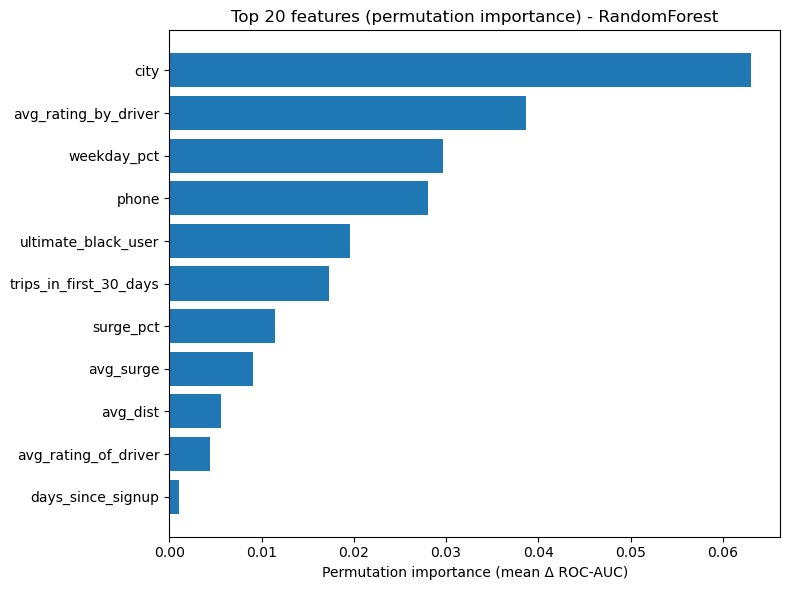

In [82]:
# Plot top permutation importances
topk = 20
top = perm.head(topk).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["perm_importance_mean"])
plt.xlabel("Permutation importance (mean Δ ROC-AUC)")
plt.title(f"Top {topk} features (permutation importance) - RandomForest")
plt.tight_layout()
plt.show()

The model indicates that retention varies significantly by city and is strongly influenced by rider behavior and experience, such as weekday usage patterns, driver ratings, and early engagement. Ultimate can leverage these insights by deploying city-specific retention strategies, improving rider experience in lower-performing markets, and encouraging weekday commuting behavior through targeted incentives during a user’s first month. Additionally, minimizing surge exposure for new users and proactively engaging users identified as high churn risk can help build early habits and improve long-term retention.